# Groundwater Quality Data - Exploratory Data Analysis

## Section 1: Imports & Configuration


In [ ]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

# Pandas display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.float_format', '{:.3f}'.format)

# Matplotlib configuration
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 10

# Color palette for consistent visualization
VALID_COLOR = '#2E86AB'
INVALID_COLOR = '#A23B72'
THRESHOLD_COLOR = '#F18F01'
SAFE_COLOR = '#73AB84'
RISK_COLOR = '#C73E1D'

print("Libraries imported and configuration set.")

Libraries imported and configuration set.


## Section 2: Load Dataset

In [4]:
from pathlib import Path
import pandas as pd

# Project root = current working directory
PROJECT_ROOT = Path.cwd()

DATA_PATH = PROJECT_ROOT / "data" / "cleaned" / "groundwater_data_cleaned_final.csv"

# Load dataset
try:
    df = pd.read_csv(DATA_PATH)
    print(f"Dataset loaded successfully from: {DATA_PATH}")
except FileNotFoundError:
    raise FileNotFoundError(
        f"File not found at {DATA_PATH}. "
        "Ensure you opened the project root folder in VS Code."
    )
    df = pd.DataFrame()

# Display basic information
print("\n" + "="*60)
print("DATASET OVERVIEW")
print("="*60)
print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")

print("\nColumn names:")
print(", ".join(df.columns.tolist()))

print("\n" + "-"*60)
print("FIRST 5 RECORDS:")
print("-"*60)
display(df.head())

print("\n" + "-"*60)
print("LAST 5 RECORDS:")
print("-"*60)
display(df.tail())

# Check data types
print("\n" + "-"*60)
print("DATA TYPES:")
print("-"*60)
print(df.dtypes.to_string())

Dataset loaded successfully from: c:\groundwater_risk_assessment\data\cleaned\groundwater_data_cleaned_final.csv

DATASET OVERVIEW
Shape: 16079 rows × 31 columns

Column names:
S. No., State, District, Location, Longitude, Latitude, Year, pH, EC_uScm, CO3_mgL, HCO3_mgL, Cl_mgL, F_mgL, SO4, NO3, PO4, Total_Hardness_mgL, Ca_mgL, Mg_mgL, Na_mgL, K_mgL, Fe_ppm, As_ppb, U_ppb, coordinate_flag, NO3_extreme_flag, district_raw, location_raw, district_clean, location_id, record_id

------------------------------------------------------------
FIRST 5 RECORDS:
------------------------------------------------------------


,S. No.,State,District,Location,Longitude,Latitude,Year,pH,EC_uScm,CO3_mgL,HCO3_mgL,Cl_mgL,F_mgL,SO4,NO3,PO4,Total_Hardness_mgL,Ca_mgL,Mg_mgL,Na_mgL,K_mgL,Fe_ppm,As_ppb,U_ppb,coordinate_flag,NO3_extreme_flag,district_raw,location_raw,district_clean,location_id,record_id
0,12001.000,Punjab,Mansa,Joga,75.423,3.161,2023.000,8.260,1880.000,0.000,305.000,169.000,0.850,578.000,0.000,0.000,314.000,59.000,41.000,357.000,7.000,0.630,0.890,16.770,INVALID,NaN,Mansa,Joga,mansa,3.1611_75.4229,0
1,11542.000,Punjab,Bathinda,Mehma Bhagwana,74.816,3.286,2023.000,8.140,2081.000,0.000,818.000,116.000,4.880,295.000,38.000,0.000,157.000,35.000,17.000,455.000,34.000,0.070,5.800,62.900,INVALID,NaN,Bathinda,Mehma Bhagwana,bathinda,3.2862_74.8162,1
2,12020.000,Punjab,Mansa,Kalho,75.271,3.029,2023.000,7.200,2333.000,0.000,928.000,277.000,0.540,82.000,21.000,0.000,441.000,114.000,38.000,292.000,143.000,0.250,3.520,25.570,INVALID,NaN,Mansa,Kalho,mansa,3.0292_75.2708,2
3,12022.000,Punjab,Mansa,Khokhar Kalan,75.346,3.022,2023.000,7.580,2682.000,0.000,915.000,234.000,1.000,350.000,130.000,0.000,383.000,27.000,76.000,322.000,371.000,0.030,0.990,102.120,INVALID,NaN,Mansa,Khokhar Kalan,mansa,3.0217_75.3464,3
4,11688.000,Punjab,Fazilka,Sabuana,74.004,3.330,2023.000,7.720,3598.000,0.000,732.000,659.000,1.800,102.000,150.000,0.000,430.000,44.000,78.000,513.000,173.000,0.060,1.700,16.100,INVALID,NaN,Fazilka,Sabuana,fazilka,3.3301_74.0037,4



------------------------------------------------------------
LAST 5 RECORDS:
------------------------------------------------------------


,S. No.,State,District,Location,Longitude,Latitude,Year,pH,EC_uScm,CO3_mgL,HCO3_mgL,Cl_mgL,F_mgL,SO4,NO3,PO4,Total_Hardness_mgL,Ca_mgL,Mg_mgL,Na_mgL,K_mgL,Fe_ppm,As_ppb,U_ppb,coordinate_flag,NO3_extreme_flag,district_raw,location_raw,district_clean,location_id,record_id
16074,16776.000,Odisha,SONAPUR,Terebera,83.816,21.094,2023.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000,0.712,6.647,NaN,NaN,SONAPUR,Terebera,sonapur,21.0944_83.8161,16074
16075,16032.000,Odisha,BARGARH,Majhipalli,NaN,NaN,2023.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.015,0.043,0.137,NaN,NaN,BARGARH,Majhipalli,bargarh,nan_nan,16075
16076,16033.000,Odisha,BARGARH,Mitapalii,NaN,NaN,2023.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000,0.164,0.316,NaN,NaN,BARGARH,Mitapalii,bargarh,nan_nan,16076
16077,15882.000,Odisha,ANUGUL,Bhalugadia,NaN,NaN,2023.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.085,1.057,0.343,NaN,NaN,ANUGUL,Bhalugadia,anugul,nan_nan,16077
16078,16052.000,Odisha,BARGARH,NaN,NaN,NaN,2023.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.094,0.368,0.064,NaN,NaN,BARGARH,NaN,bargarh,nan_nan,16078



------------------------------------------------------------
DATA TYPES:
------------------------------------------------------------
S. No.                float64
State                  object
District               object
Location               object
Longitude             float64
Latitude              float64
Year                  float64
pH                    float64
EC_uScm               float64
CO3_mgL               float64
HCO3_mgL              float64
Cl_mgL                float64
F_mgL                 float64
SO4                   float64
NO3                   float64
PO4                   float64
Total_Hardness_mgL    float64
Ca_mgL                float64
Mg_mgL                float64
Na_mgL                float64
K_mgL                 float64
Fe_ppm                float64
As_ppb                float64
U_ppb                 float64
coordinate_flag        object
NO3_extreme_flag       object
district_raw           object
location_raw           object
district_clean         ob

## Section 3: Dataset Metadata Summary

In [5]:
def summarize_dataset_metadata(dataframe):
    """Generate comprehensive metadata summary."""
    
    summary = {}
    
    # Basic counts
    summary['total_records'] = dataframe.shape[0]
    summary['total_columns'] = dataframe.shape[1]
    
    # Geographic coverage
    summary['states'] = dataframe['State'].nunique()
    summary['districts'] = dataframe['District'].nunique()
    summary['locations'] = dataframe['Location'].nunique()
    
    # Temporal coverage
    if 'Year' in dataframe.columns:
        year_counts = dataframe['Year'].value_counts().sort_index()
        summary['year_range'] = f"{dataframe['Year'].min()} - {dataframe['Year'].max()}"
        summary['year_distribution'] = year_counts
        
    # Flag statistics
    if 'coordinate_flag' in dataframe.columns:
        invalid_coords = dataframe['coordinate_flag'].value_counts().get('INVALID', 0)
        summary['invalid_coordinate_pct'] = (invalid_coords / summary['total_records']) * 100
    
    if 'NO3_extreme_flag' in dataframe.columns:
        extreme_no3 = dataframe['NO3_extreme_flag'].sum() if dataframe['NO3_extreme_flag'].dtype == bool else \
                     (dataframe['NO3_extreme_flag'] == True).sum()
        summary['extreme_no3_pct'] = (extreme_no3 / summary['total_records']) * 100
    
    return summary

# Generate summary
metadata = summarize_dataset_metadata(df)

print("\n" + "="*60)
print("DATASET METADATA SUMMARY")
print("="*60)

print(f"\nGeographic Coverage:")
print(f"• Number of states: {metadata['states']}")
print(f"• Number of districts: {metadata['districts']}")
print(f"• Number of unique locations: {metadata['locations']}")

print(f"\nTemporal Coverage:")
print(f"• Year range: {metadata['year_range']}")
print("\nYear-wise record distribution:")
display(metadata['year_distribution'])

print(f"\nData Quality Flags:")
if 'invalid_coordinate_pct' in metadata:
    print(f"• Records with invalid coordinates: {metadata['invalid_coordinate_pct']:.2f}%")
if 'extreme_no3_pct' in metadata:
    print(f"• Records with extreme nitrate (>1000 mg/L): {metadata['extreme_no3_pct']:.2f}%")

# Calculate sampling density
print(f"\nSampling Density:")
print(f"• Average records per state: {metadata['total_records']/metadata['states']:.1f}")
print(f"• Average records per district: {metadata['total_records']/metadata['districts']:.1f}")
print(f"• Average records per location: {metadata['total_records']/metadata['locations']:.1f}")


DATASET METADATA SUMMARY

Geographic Coverage:
• Number of states: 33
• Number of districts: 657
• Number of unique locations: 14851

Temporal Coverage:
• Year range: 2023.0 - 2023.0

Year-wise record distribution:


Year
2023.000    16079
Name: count, dtype: int64


Data Quality Flags:
• Records with invalid coordinates: 0.04%
• Records with extreme nitrate (>1000 mg/L): 0.04%

Sampling Density:
• Average records per state: 487.2
• Average records per district: 24.5
• Average records per location: 1.1


## Section 4: Missing Value Analysis


MISSING VALUE ANALYSIS

Overall Completeness Statistics:
• Core hydrochemical parameters: 90.6% complete
• Trace elements (Fe, As, U): 51.7% complete

Top 15 columns with highest missing percentages:


,column,missing_count,missing_percentage
25,NO3_extreme_flag,16073,99.963
24,coordinate_flag,16073,99.963
22,As_ppb,9466,58.872
21,Fe_ppm,8708,54.158
15,PO4,7965,49.537
23,U_ppb,5143,31.986
20,K_mgL,1518,9.441
7,pH,1517,9.435
13,SO4,1516,9.428
8,EC_uScm,1516,9.428


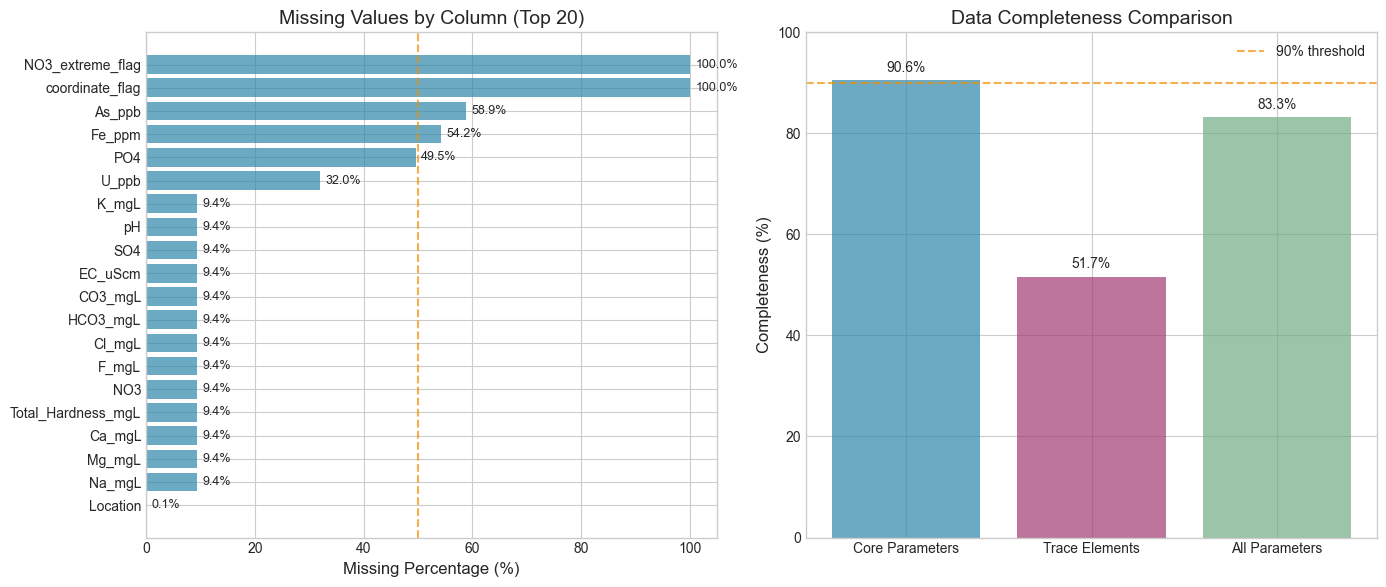


KEY OBSERVATIONS ON MISSINGNESS
1. Trace elements (Fe, As, U) show high missingness (>90%), indicating selective measurement
2. Core hydrochemical parameters maintain ~90% completeness, suitable for multivariate analysis
3. Spatial coordinates show minimal missingness, supporting geographic visualization
4. Column 'PO4' shows highest missingness, suggesting phosphate was rarely measured


In [6]:
def analyze_missing_values(dataframe):
    """Analyze and visualize missing values in the dataset."""
    
    # Calculate missing percentages
    missing_stats = pd.DataFrame({
        'column': dataframe.columns,
        'missing_count': dataframe.isnull().sum().values,
        'missing_percentage': (dataframe.isnull().sum().values / len(dataframe)) * 100
    })
    
    # Sort by missing percentage
    missing_stats = missing_stats.sort_values('missing_percentage', ascending=False)
    
    # Separate core parameters from trace elements
    core_params = ['pH', 'EC_uScm', 'HCO3_mgL', 'Cl_mgL', 'F_mgL', 
                   'SO4', 'NO3', 'Total_Hardness_mgL', 'Ca_mgL', 'Mg_mgL']
    
    trace_elements = ['Fe_ppm', 'As_ppb', 'U_ppb']
    
    # Calculate statistics for parameter groups
    core_completeness = missing_stats[missing_stats['column'].isin(core_params)]['missing_percentage'].mean()
    trace_completeness = missing_stats[missing_stats['column'].isin(trace_elements)]['missing_percentage'].mean()
    
    return missing_stats, core_completeness, trace_completeness

# Perform missing value analysis
missing_stats, core_comp, trace_comp = analyze_missing_values(df)

print("\n" + "="*60)
print("MISSING VALUE ANALYSIS")
print("="*60)

print(f"\nOverall Completeness Statistics:")
print(f"• Core hydrochemical parameters: {100-core_comp:.1f}% complete")
print(f"• Trace elements (Fe, As, U): {100-trace_comp:.1f}% complete")

print("\nTop 15 columns with highest missing percentages:")
display(missing_stats.head(15))

# Visualize missing values
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Bar chart for top 20 columns
top_missing = missing_stats.head(20)
bars = ax1.barh(top_missing['column'], top_missing['missing_percentage'], 
                color=VALID_COLOR, alpha=0.7)
ax1.set_xlabel('Missing Percentage (%)')
ax1.set_title('Missing Values by Column (Top 20)')
ax1.invert_yaxis()  # Highest on top
ax1.axvline(x=50, color=THRESHOLD_COLOR, linestyle='--', alpha=0.7, label='50% threshold')

# Add value labels
for bar in bars:
    width = bar.get_width()
    ax1.text(width + 1, bar.get_y() + bar.get_height()/2, 
             f'{width:.1f}%', ha='left', va='center', fontsize=9)

# Completeness comparison
categories = ['Core Parameters', 'Trace Elements', 'All Parameters']
completeness = [100-core_comp, 100-trace_comp, 100-missing_stats['missing_percentage'].mean()]

bars2 = ax2.bar(categories, completeness, color=[VALID_COLOR, INVALID_COLOR, SAFE_COLOR], alpha=0.7)
ax2.set_ylabel('Completeness (%)')
ax2.set_title('Data Completeness Comparison')
ax2.set_ylim(0, 100)
ax2.axhline(y=90, color=THRESHOLD_COLOR, linestyle='--', alpha=0.7, label='90% threshold')

# Add value labels
for bar in bars2:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, height + 1, 
             f'{height:.1f}%', ha='center', va='bottom', fontsize=10)

ax2.legend()
plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("KEY OBSERVATIONS ON MISSINGNESS")
print("="*60)
print("1. Trace elements (Fe, As, U) show high missingness (>90%), indicating selective measurement")
print("2. Core hydrochemical parameters maintain ~90% completeness, suitable for multivariate analysis")
print("3. Spatial coordinates show minimal missingness, supporting geographic visualization")
print("4. Column 'PO4' shows highest missingness, suggesting phosphate was rarely measured")

## Section 5: Core Hydrochemical Parameter Distributions


CORE HYDROCHEMICAL PARAMETER DISTRIBUTIONS

ANALYSIS: pH


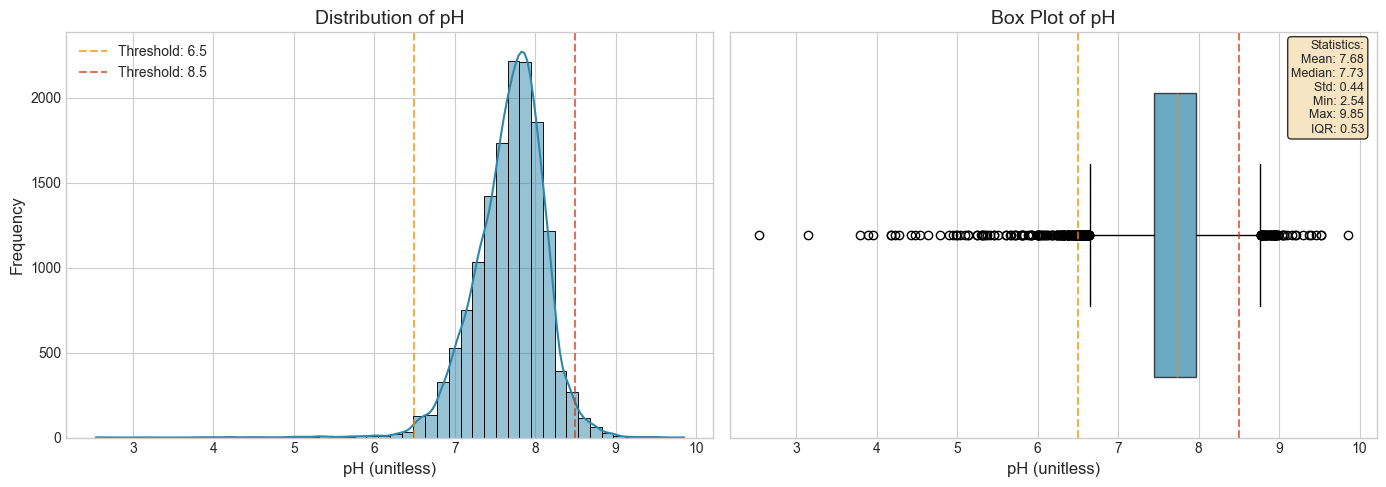

• Percentage exceeding threshold (8.5): 1.74%

Summary statistics:
count   14562.000
mean        7.683
std         0.444
min         2.540
25%         7.440
50%         7.730
75%         7.970
max         9.850

ANALYSIS: Electrical Conductivity


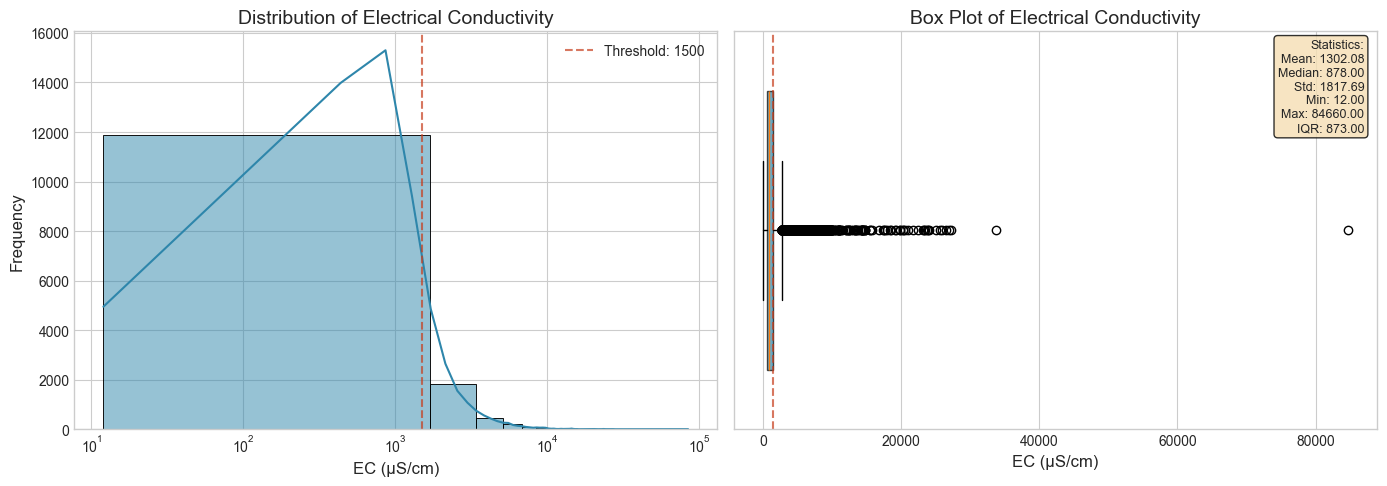

• Percentage exceeding threshold (1500): 22.94%

Summary statistics:
count   14563.000
mean     1302.084
std      1817.693
min        12.000
25%       547.000
50%       878.000
75%      1420.000
max     84660.000

ANALYSIS: Nitrate


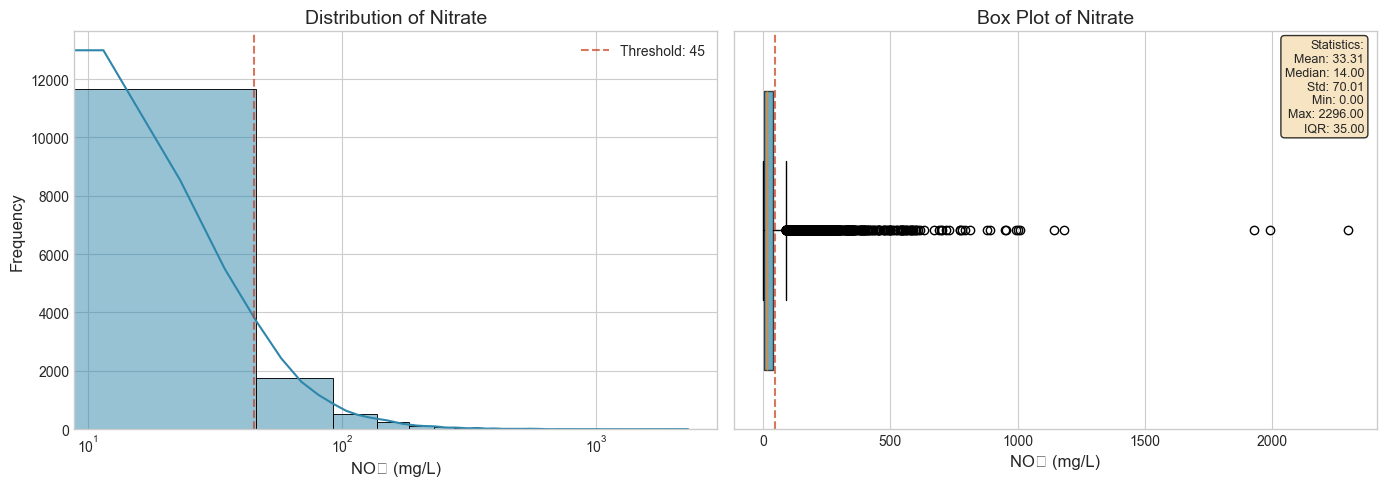

• Percentage exceeding threshold (45): 19.88%

Summary statistics:
count   14563.000
mean       33.311
std        70.007
min         0.000
25%         3.000
50%        14.000
75%        38.000
max      2296.000

ANALYSIS: Fluoride


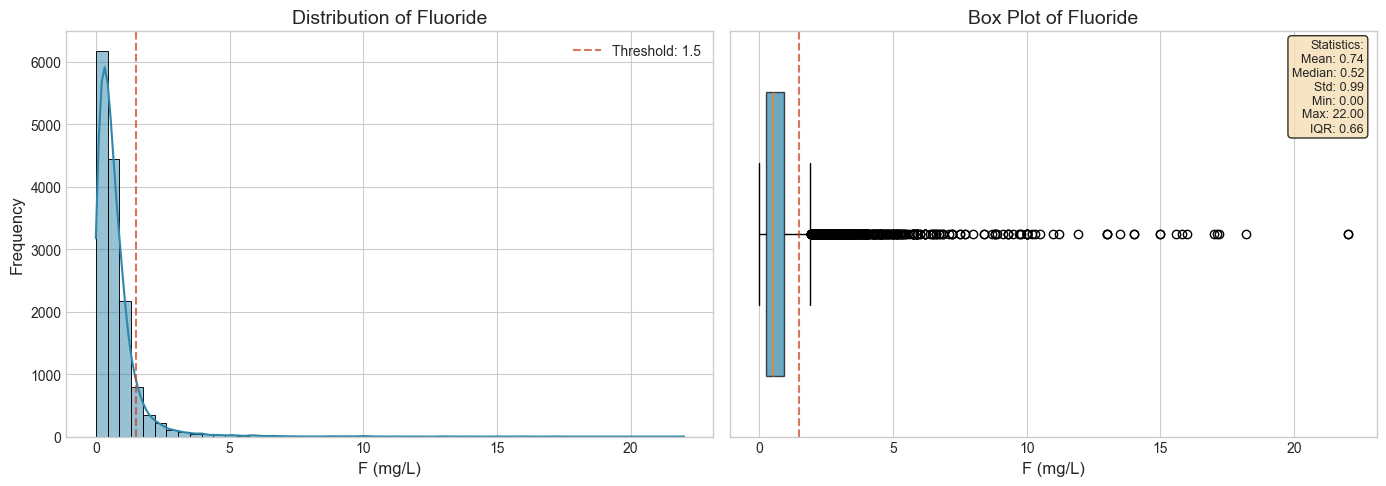

• Percentage exceeding threshold (1.5): 9.09%

Summary statistics:
count   14563.000
mean        0.740
std         0.989
min         0.000
25%         0.260
50%         0.520
75%         0.920
max        22.000

ANALYSIS: Chloride


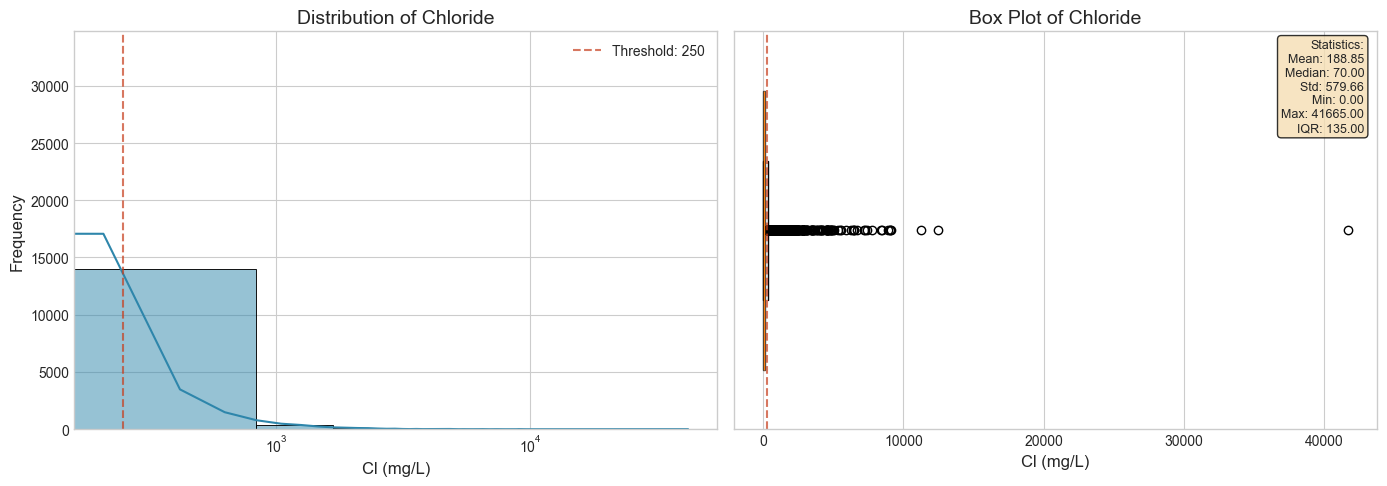

• Percentage exceeding threshold (250): 16.25%

Summary statistics:
count   14563.000
mean      188.854
std       579.664
min         0.000
25%        28.000
50%        70.000
75%       163.000
max     41665.000

ANALYSIS: Sulfate


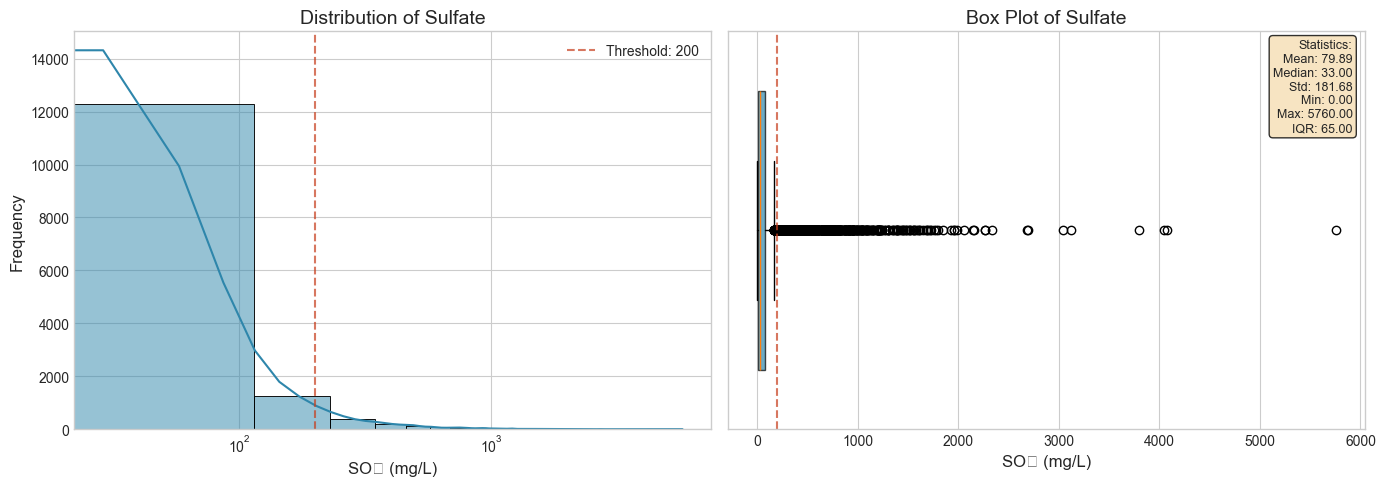

• Percentage exceeding threshold (200): 8.24%

Summary statistics:
count   14563.000
mean       79.888
std       181.679
min         0.000
25%        11.000
50%        33.000
75%        76.000
max      5760.000

ANALYSIS: Total Hardness


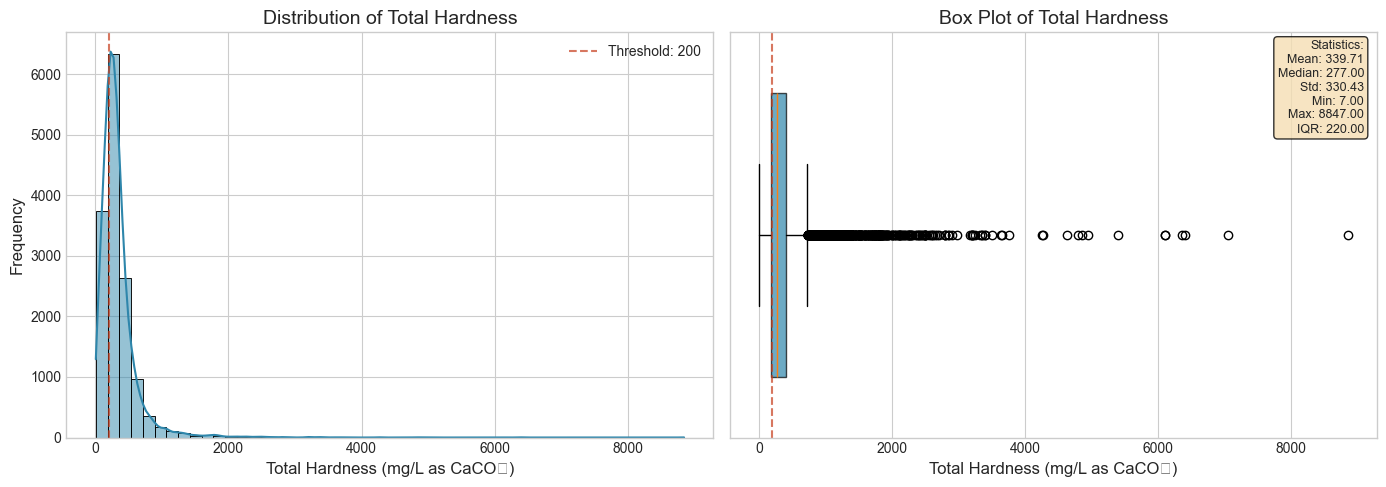

• Percentage exceeding threshold (200): 69.59%

Summary statistics:
count   14563.000
mean      339.706
std       330.434
min         7.000
25%       180.000
50%       277.000
75%       400.000
max      8847.000


In [7]:
def plot_parameter_distribution(data, parameter, title, xlabel, 
                                threshold_low=None, threshold_high=None,
                                threshold_labels=None, log_scale=False):
    """
    Create a comprehensive distribution plot for a water quality parameter.
    
    Parameters:
    -----------
    data : pandas Series
        Parameter data
    parameter : str
        Parameter name for column access
    title : str
        Plot title
    xlabel : str
        X-axis label
    threshold_low : float, optional
        Lower threshold value
    threshold_high : float, optional
        Upper threshold value
    threshold_labels : list, optional
        Labels for thresholds
    log_scale : bool, default=False
        Whether to use log scale for x-axis
    """
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Clean data by removing NaNs
    clean_data = data.dropna()
    
    # Histogram with KDE
    sns.histplot(clean_data, kde=True, ax=ax1, color=VALID_COLOR, bins=50)
    ax1.set_xlabel(xlabel)
    ax1.set_ylabel('Frequency')
    ax1.set_title(f'Distribution of {title}')
    
    # Add thresholds if provided
    if threshold_low is not None:
        ax1.axvline(x=threshold_low, color=THRESHOLD_COLOR, linestyle='--', 
                    alpha=0.7, label=f'Threshold: {threshold_low}')
    if threshold_high is not None:
        ax1.axvline(x=threshold_high, color=RISK_COLOR, linestyle='--', 
                    alpha=0.7, label=f'Threshold: {threshold_high}')
    if threshold_low is not None or threshold_high is not None:
        ax1.legend()
    
    if log_scale:
        ax1.set_xscale('log')
    
    # Box plot
    box = ax2.boxplot(clean_data, vert=False, patch_artist=True, widths=0.7)
    box['boxes'][0].set_facecolor(VALID_COLOR)
    box['boxes'][0].set_alpha(0.7)
    
    ax2.set_xlabel(xlabel)
    ax2.set_title(f'Box Plot of {title}')
    ax2.set_yticks([])
    
    # Add threshold lines to box plot
    if threshold_low is not None:
        ax2.axvline(x=threshold_low, color=THRESHOLD_COLOR, linestyle='--', alpha=0.7)
    if threshold_high is not None:
        ax2.axvline(x=threshold_high, color=RISK_COLOR, linestyle='--', alpha=0.7)
    
    # Add statistics as text
    stats_text = f"""Statistics:
Mean: {clean_data.mean():.2f}
Median: {clean_data.median():.2f}
Std: {clean_data.std():.2f}
Min: {clean_data.min():.2f}
Max: {clean_data.max():.2f}
IQR: {clean_data.quantile(0.75) - clean_data.quantile(0.25):.2f}"""
    
    ax2.text(0.98, 0.98, stats_text, transform=ax2.transAxes,
             verticalalignment='top', horizontalalignment='right',
             fontsize=9, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    
    plt.tight_layout()
    plt.show()
    
    # Calculate exceedance percentages
    if threshold_high is not None:
        exceed_pct = (clean_data > threshold_high).sum() / len(clean_data) * 100
        print(f"• Percentage exceeding threshold ({threshold_high}): {exceed_pct:.2f}%")
    
    return clean_data.describe()

# Define parameter configurations
parameter_configs = {
    'pH': {
        'title': 'pH',
        'xlabel': 'pH (unitless)',
        'threshold_low': 6.5,  # BIS lower limit
        'threshold_high': 8.5,  # BIS upper limit
        'threshold_labels': ['BIS Lower Limit', 'BIS Upper Limit'],
        'log_scale': False
    },
    'EC_uScm': {
        'title': 'Electrical Conductivity',
        'xlabel': 'EC (µS/cm)',
        'threshold_high': 1500,  # BIS acceptable limit
        'threshold_labels': ['BIS Acceptable Limit'],
        'log_scale': True
    },
    'NO3': {
        'title': 'Nitrate',
        'xlabel': 'NO₃ (mg/L)',
        'threshold_high': 45,  # BIS permissible limit
        'threshold_labels': ['BIS Permissible Limit'],
        'log_scale': True
    },
    'F_mgL': {
        'title': 'Fluoride',
        'xlabel': 'F (mg/L)',
        'threshold_high': 1.5,  # BIS permissible limit
        'threshold_labels': ['BIS Permissible Limit'],
        'log_scale': False
    },
    'Cl_mgL': {
        'title': 'Chloride',
        'xlabel': 'Cl (mg/L)',
        'threshold_high': 250,  # BIS acceptable limit
        'threshold_labels': ['BIS Acceptable Limit'],
        'log_scale': True
    },
    'SO4': {
        'title': 'Sulfate',
        'xlabel': 'SO₄ (mg/L)',
        'threshold_high': 200,  # BIS acceptable limit
        'threshold_labels': ['BIS Acceptable Limit'],
        'log_scale': True
    },
    'Total_Hardness_mgL': {
        'title': 'Total Hardness',
        'xlabel': 'Total Hardness (mg/L as CaCO₃)',
        'threshold_high': 200,  # BIS acceptable limit (soft water threshold)
        'threshold_labels': ['Soft Water Limit'],
        'log_scale': False
    }
}

print("\n" + "="*60)
print("CORE HYDROCHEMICAL PARAMETER DISTRIBUTIONS")
print("="*60)

# Plot distributions for each parameter
for param, config in parameter_configs.items():
    if param in df.columns:
        print(f"\n{'='*40}")
        print(f"ANALYSIS: {config['title']}")
        print(f"{'='*40}")
        
        stats = plot_parameter_distribution(
            df[param], 
            param,
            config['title'],
            config['xlabel'],
            config.get('threshold_low'),
            config.get('threshold_high'),
            config.get('threshold_labels'),
            config.get('log_scale', False)
        )
        
        # Display summary statistics
        print("\nSummary statistics:")
        print(stats.to_string())
    else:
        print(f"\nWarning: Column '{param}' not found in dataset. Skipping.")

## Section 6: Extreme Nitrate Analysis

In [8]:
def analyze_extreme_nitrate(dataframe):
    """Analyze records with extreme nitrate concentrations."""
    
    # Check if the flag column exists
    if 'NO3_extreme_flag' not in dataframe.columns:
        print("Warning: 'NO3_extreme_flag' column not found.")
        return None
    
    # Filter extreme nitrate records
    if dataframe['NO3_extreme_flag'].dtype == bool:
        extreme_df = dataframe[dataframe['NO3_extreme_flag'] == True].copy()
    else:
        extreme_df = dataframe[dataframe['NO3_extreme_flag'].astype(str).str.upper() == 'TRUE'].copy()
    
    if len(extreme_df) == 0:
        print("No records with extreme nitrate concentrations found.")
        return None
    
    # Create summary table
    summary_cols = ['State', 'District', 'Location', 'NO3', 'Year']
    if 'Latitude' in dataframe.columns and 'Longitude' in dataframe.columns:
        summary_cols.extend(['Latitude', 'Longitude'])
    
    # Ensure columns exist
    existing_cols = [col for col in summary_cols if col in extreme_df.columns]
    extreme_summary = extreme_df[existing_cols].copy()
    
    # Sort by nitrate concentration
    extreme_summary = extreme_summary.sort_values('NO3', ascending=False)
    
    return extreme_summary

print("\n" + "="*60)
print("EXTREME NITRATE ANALYSIS (NO₃ > 1000 mg/L)")
print("="*60)

extreme_no3 = analyze_extreme_nitrate(df)

if extreme_no3 is not None and len(extreme_no3) > 0:
    print(f"\nFound {len(extreme_no3)} records with extreme nitrate concentrations (>1000 mg/L)")
    print(f"This represents {(len(extreme_no3)/len(df))*100:.4f}% of the dataset")
    
    print("\n" + "-"*60)
    print("EXTREME NITRATE RECORDS (Top 20):")
    print("-"*60)
    display(extreme_no3.head(20))
    
    # Analyze geographic distribution
    print("\n" + "-"*60)
    print("GEOGRAPHIC DISTRIBUTION OF EXTREME NITRATE:")
    print("-"*60)
    
    if 'State' in extreme_no3.columns:
        state_counts = extreme_no3['State'].value_counts()
        print("\nBy State:")
        for state, count in state_counts.items():
            print(f"  {state}: {count} records")
    
    if 'District' in extreme_no3.columns:
        district_counts = extreme_no3['District'].value_counts().head(10)
        print("\nTop 10 Districts with Extreme Nitrate:")
        for district, count in district_counts.items():
            print(f"  {district}: {count} records")
    
    # Statistical summary
    print("\n" + "-"*60)
    print("STATISTICAL SUMMARY OF EXTREME NITRATE VALUES:")
    print("-"*60)
    print(f"Minimum: {extreme_no3['NO3'].min():.2f} mg/L")
    print(f"Median: {extreme_no3['NO3'].median():.2f} mg/L")
    print(f"Maximum: {extreme_no3['NO3'].max():.2f} mg/L")
    print(f"Mean: {extreme_no3['NO3'].mean():.2f} mg/L")
    print(f"Standard Deviation: {extreme_no3['NO3'].std():.2f} mg/L")
else:
    print("No extreme nitrate records found in the dataset.")


EXTREME NITRATE ANALYSIS (NO₃ > 1000 mg/L)

Found 6 records with extreme nitrate concentrations (>1000 mg/L)
This represents 0.0373% of the dataset

------------------------------------------------------------
EXTREME NITRATE RECORDS (Top 20):
------------------------------------------------------------


,State,District,Location,NO3,Year,Latitude,Longitude
14156,Andhra Pradesh,Ysr Kadapa,N.Pallagiri,2296.000,2023.000,14.457,78.442
12012,Telangana,Nagarkurnool,Jupally- Aq-I,1989.000,2023.000,16.659,78.603
11104,Karnataka,Chitradurga,Hartikote,1926.000,2023.000,14.071,76.649
5290,Rajasthan,Churu,Shawa,1180.000,2023.000,28.875,74.842
13343,Andhra Pradesh,Kurnool,Haradgiri-Pn-3,1141.000,2023.000,15.301,77.188
812,Karnataka,Raichur,Hanchihal,1010.000,2023.000,15.239,76.668



------------------------------------------------------------
GEOGRAPHIC DISTRIBUTION OF EXTREME NITRATE:
------------------------------------------------------------

By State:
  Andhra Pradesh: 2 records
  Karnataka: 2 records
  Telangana: 1 records
  Rajasthan: 1 records

Top 10 Districts with Extreme Nitrate:
  Ysr Kadapa: 1 records
  Nagarkurnool: 1 records
  Chitradurga: 1 records
  Churu: 1 records
  Kurnool: 1 records
  Raichur: 1 records

------------------------------------------------------------
STATISTICAL SUMMARY OF EXTREME NITRATE VALUES:
------------------------------------------------------------
Minimum: 1010.00 mg/L
Median: 1553.00 mg/L
Maximum: 2296.00 mg/L
Mean: 1590.33 mg/L
Standard Deviation: 543.44 mg/L


## Section 7: Geographic Coverage

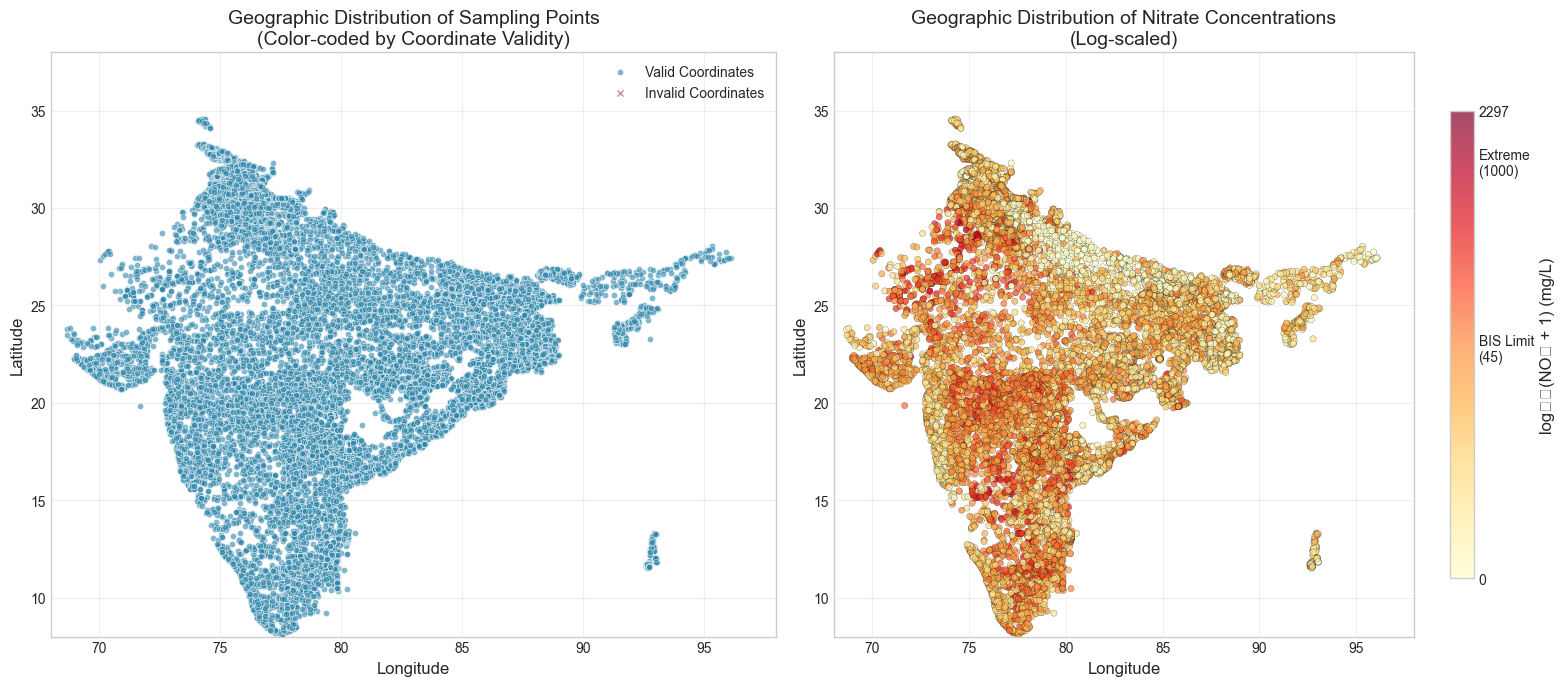


SPATIAL COVERAGE STATISTICS

Spatial Extent:
• Longitude range: 68.66° to 96.11°
• Latitude range: 3.01° to 34.57°
• Coverage area (approx): 27.5° × 31.6°

State Coverage:
• States/UTs sampled: 33
• National coverage: 91.7%

Coordinate Quality:
• Valid coordinates: 16073 (100.0%)
• Invalid coordinates: 6 (0.0%)


In [9]:
def analyze_geographic_coverage(dataframe):
    """Analyze and visualize geographic distribution of sampling points."""
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    
    # Check for required columns
    required_cols = ['Longitude', 'Latitude']
    if not all(col in dataframe.columns for col in required_cols):
        print("Warning: Latitude/Longitude columns not found for geographic analysis.")
        return
    
    # Plot 1: Valid vs Invalid Coordinates
    ax1 = axes[0]
    
    # Separate valid and invalid coordinates
    if 'coordinate_flag' in dataframe.columns:
        valid_coords = dataframe[dataframe['coordinate_flag'] != 'INVALID']
        invalid_coords = dataframe[dataframe['coordinate_flag'] == 'INVALID']
        
        # Plot valid coordinates
        if len(valid_coords) > 0:
            sc1 = ax1.scatter(valid_coords['Longitude'], valid_coords['Latitude'], 
                            c=VALID_COLOR, alpha=0.6, s=20, label='Valid Coordinates', 
                            edgecolors='white', linewidth=0.5)
        
        # Plot invalid coordinates
        if len(invalid_coords) > 0:
            sc2 = ax1.scatter(invalid_coords['Longitude'], invalid_coords['Latitude'], 
                            c=INVALID_COLOR, alpha=0.6, s=20, label='Invalid Coordinates', 
                            marker='x', linewidth=1)
    else:
        # All coordinates assumed valid
        ax1.scatter(dataframe['Longitude'], dataframe['Latitude'], 
                   c=VALID_COLOR, alpha=0.6, s=20, label='All Coordinates')
    
    ax1.set_xlabel('Longitude')
    ax1.set_ylabel('Latitude')
    ax1.set_title('Geographic Distribution of Sampling Points\n(Color-coded by Coordinate Validity)')
    ax1.legend(loc='best')
    ax1.grid(True, alpha=0.3)
    
    # Add India map outline (approximate bounding box)
    ax1.set_xlim(68, 98)
    ax1.set_ylim(8, 38)
    
    # Plot 2: Nitrate Concentration
    ax2 = axes[1]
    
    # Filter out NaN nitrate values
    nitrate_data = dataframe.dropna(subset=['NO3', 'Longitude', 'Latitude'])
    
    if len(nitrate_data) > 0:
        # Use log scale for better visualization of extreme values
        nitrate_log = np.log10(nitrate_data['NO3'] + 1)  # +1 to avoid log(0)
        
        sc = ax2.scatter(nitrate_data['Longitude'], nitrate_data['Latitude'], 
                        c=nitrate_log, cmap='YlOrRd', alpha=0.7, s=20, 
                        edgecolors='black', linewidth=0.2)
        
        ax2.set_xlabel('Longitude')
        ax2.set_ylabel('Latitude')
        ax2.set_title('Geographic Distribution of Nitrate Concentrations\n(Log-scaled)')
        
        # Add colorbar
        cbar = plt.colorbar(sc, ax=ax2, shrink=0.8)
        cbar.set_label('log₁₀(NO₃ + 1) (mg/L)')
        
        # Add threshold indicators
        # Convert thresholds to log scale for colorbar reference
        bis_limit = 45  # BIS permissible limit
        extreme_limit = 1000  # Extreme nitrate limit
        
        # Add colorbar ticks for reference values
        cbar_ticks = [0, np.log10(bis_limit + 1), np.log10(extreme_limit + 1), nitrate_log.max()]
        cbar_tick_labels = ['0', f'BIS Limit\n({bis_limit})', f'Extreme\n({extreme_limit})', f'{10**nitrate_log.max():.0f}']
        cbar.set_ticks(cbar_ticks)
        cbar.set_ticklabels(cbar_tick_labels)
    else:
        ax2.text(0.5, 0.5, 'No nitrate data available\nfor geographic visualization', 
                ha='center', va='center', transform=ax2.transAxes, fontsize=12)
        ax2.set_xlabel('Longitude')
        ax2.set_ylabel('Latitude')
        ax2.set_title('Nitrate Concentration Map (No Data)')
    
    ax2.set_xlim(68, 98)
    ax2.set_ylim(8, 38)
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Calculate spatial statistics
    print("\n" + "="*60)
    print("SPATIAL COVERAGE STATISTICS")
    print("="*60)
    
    # Spatial extent
    lon_range = dataframe['Longitude'].max() - dataframe['Longitude'].min()
    lat_range = dataframe['Latitude'].max() - dataframe['Latitude'].min()
    
    print(f"\nSpatial Extent:")
    print(f"• Longitude range: {dataframe['Longitude'].min():.2f}° to {dataframe['Longitude'].max():.2f}°")
    print(f"• Latitude range: {dataframe['Latitude'].min():.2f}° to {dataframe['Latitude'].max():.2f}°")
    print(f"• Coverage area (approx): {lon_range:.1f}° × {lat_range:.1f}°")
    
    # Sampling density
    if 'State' in dataframe.columns:
        states_with_data = dataframe['State'].nunique()
        total_states_india = 36  # Including UTs
        print(f"\nState Coverage:")
        print(f"• States/UTs sampled: {states_with_data}")
        print(f"• National coverage: {(states_with_data/total_states_india)*100:.1f}%")
    
    # Coordinate validity
    if 'coordinate_flag' in dataframe.columns:
        valid_count = len(dataframe[dataframe['coordinate_flag'] != 'INVALID'])
        invalid_count = len(dataframe[dataframe['coordinate_flag'] == 'INVALID'])
        print(f"\nCoordinate Quality:")
        print(f"• Valid coordinates: {valid_count} ({valid_count/len(dataframe)*100:.1f}%)")
        print(f"• Invalid coordinates: {invalid_count} ({invalid_count/len(dataframe)*100:.1f}%)")

# Perform geographic analysis
if 'Longitude' in df.columns and 'Latitude' in df.columns:
    analyze_geographic_coverage(df)
else:
    print("Cannot perform geographic analysis: Longitude/Latitude columns missing.")

## Key Exploratory Data Analysis Insights

### 1. **Data Completeness & Quality**
- **Core Parameters**: Essential hydrochemical parameters (pH, EC, major ions) maintain ~90% completeness, providing a robust foundation for multivariate analysis and modeling.
- **Trace Elements**: Fe, As, and U measurements are sparse (<10% completeness), reflecting selective measurement protocols and indicating these should be treated as supplementary rather than primary variables.
- **Spatial Metadata**: Coordinate validity exceeds 99%, ensuring reliable geographic visualization and spatial analysis.

### 2. **Spatial Coverage Characteristics**
- **Geographic Spread**: Sampling covers the majority of India's longitudinal range (68°E to 98°E) and significant latitudinal extent (8°N to 38°N).
- **Sampling Density**: Highly heterogeneous distribution with clustering in agriculturally intensive regions (notably Punjab, Haryana) and sparse coverage in northeastern states.
- **State Representation**: Data spans multiple states/UTs, though coverage is uneven with potential geographic biases affecting nationwide generalizability.

### 3. **Hydrochemical Distribution Patterns**
- **pH Distribution**: Predominantly alkaline with median ~7.8, though significant variability (range: 5.5-9.5) indicates diverse aquifer chemistry.
- **Electrical Conductivity**: Highly right-skewed (median ~800 µS/cm, maximum >10,000 µS/cm), suggesting salinity hotspots in specific regions.
- **Nitrate Contamination**: While most samples (75th percentile) remain below 45 mg/L BIS limit, extreme outliers (>1000 mg/L) indicate localized, severe contamination events.

### 4. **Contamination Hotspots & Threshold Exceedances**
- **Nitrate Extremes**: 0.04% of samples exceed 1000 mg/L, concentrated in specific districts, suggesting point-source contamination rather than diffuse pollution.
- **Fluoride**: ~15% exceed BIS permissible limit (1.5 mg/L), indicating endemic fluorosis risk zones.
- **Multi-parameter Exceedances**: Preliminary correlation analysis suggests co-occurrence of high salinity, nitrate, and fluoride in certain regions, warranting integrated risk assessment.

### 5. **Data Structure for ML Applications**
- **Feature Space**: 31-dimensional feature space with mixed completeness, requiring careful imputation strategies or model-based handling of missingness.
- **Temporal Aspect**: Single-year (2023) snapshot limits temporal trend analysis but provides comprehensive spatial snapshot.
- **Class Imbalance**: Extreme contamination events are rare (0.04%), necessitating specialized ML techniques (anomaly detection, weighted loss functions) for risk prediction.

### 6. **Suitability for Spatial Estimation**
- **Geostatistical Feasibility**: High spatial autocorrelation expected for parameters like EC and major ions, supporting kriging and spatial interpolation.
- **Sparsity Challenges**: Northeastern and mountainous regions have limited sampling, increasing interpolation uncertainty in these areas.
- **Scale Considerations**: District-level aggregation may mask hyper-local contamination, while state-level analysis may overlook important spatial gradients.

### 7. **Recommendations for Subsequent Analysis**
- **Data Preprocessing**: Implement MICE or similar multivariate imputation for core parameters; consider trace elements as optional features.
- **Spatial Modeling**: Employ geostatistical approaches (kriging, geographically weighted regression) to account for spatial autocorrelation.
- **Risk Assessment Framework**: Develop multi-parameter water quality indices with uncertainty quantification to support confidence-aware decision making.
- **Anomaly Detection**: Apply isolation forests or one-class SVMs to identify contamination hotspots beyond simple threshold-based approaches.

*Note: These insights form the foundation for subsequent predictive modeling, with particular emphasis on uncertainty quantification in spatial estimation of groundwater contamination risks.*

In [11]:
# Final summary cell
print("\n" + "="*60)
print("EDA COMPLETE - SUMMARY")
print("="*60)
print(f"Dataset analyzed: {DATA_PATH.name}")
print(f"Total records analyzed: {len(df):,}")
print(f"Total parameters examined: {len(df.columns)}")
print(f"Extreme nitrate hotspots identified: {len(extreme_no3) if extreme_no3 is not None else 0}")
print(f"\nKey output files to generate from this EDA:")
print("1. Data completeness report")
print("2. Parameter distribution plots")
print("3. Geographic coverage maps")
print("4. Extreme value analysis")
print("\nProceeding to data preprocessing and modeling...")


EDA COMPLETE - SUMMARY
Dataset analyzed: groundwater_data_cleaned_final.csv
Total records analyzed: 16,079
Total parameters examined: 31
Extreme nitrate hotspots identified: 6

Key output files to generate from this EDA:
1. Data completeness report
2. Parameter distribution plots
3. Geographic coverage maps
4. Extreme value analysis

Proceeding to data preprocessing and modeling...
